# Models for Outcomes

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import shap
import numpy as np
from itertools import product
from pathlib import Path
import os

/global/homes/j/jbbutler/.conda/envs/antarctic_ars/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


ModuleNotFoundError: No module named 'shap'

In [19]:
load_path = Path(os.getcwd()).parents[0]/Path('dataset/datasets/model_ready/train.csv')
train_data = pd.read_csv(load_path, index_col='Label')

In [26]:
X = train_data[['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_landfalling_omega500', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']]
snow_var = 'cumulative_snowfall_ais'

## Non-extreme outcomes

For modelling relationships between covariates and the average of the outcome variable among all ARs, we use the `xgboost` algorithm and assess variable importance via partial dependence plots at SHAP values.

In [147]:
# some basic cross validation
# for snowfall
etas = np.linspace(0.0001,0.3,11)
# units of Y are in gigatons, a loss of 1 will be really
# high, so that seems like a reasonable upper bound
gammas = np.linspace(0,1,10)
# intuition tells me we won't need to go THAT deep
max_depth = np.arange(10) + 1
# don't have a great intuition on this, mostly testing
lambdas = np.linspace(0, 2, 11)
# same
min_child_weights = np.linspace(0, 3, 11)

# since we're doing early stopping, this should be good
nrounds = 500
early_stopping_rounds = 10

tree_method = 'exact'
booster = 'gbtree'

In [148]:
hyperparams_lst = list(product(gammas, max_depth, lambdas, min_child_weights))

In [161]:
def process_hyperparam_chunk(lst):
    etas = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.3])
    num_eta = len(etas)
    results_lst = np.zeros((len(etas)*len(lst), len(lst[0]) + 3))
    
    for i, param_set in enumerate(lst):
        for j, eta in enumerate(etas):
            params = dict(booster='gbtree',
                   eta=eta,
                   gamma=param_set[0],
                   max_depth=param_set[1],
                   reg_lambda=param_set[2],
                   min_child_weight=param_set[3],
                   tree_method=tree_method)
            dtrain = xgb.DMatrix(X, label=train_data[snow_var])
            res = xgb.cv(params,
                   dtrain,
                   nrounds,
                   nfold=5,
                   seed=12345,
                   early_stopping_rounds=early_stopping_rounds)
            results_lst[i*num_eta + j,:] = np.array(list(param_set) + [eta] + [res.shape[0]] + [float(res['test-rmse-mean'].iloc[-1])])

    return results_lst

In [171]:
chunk_lst = []
chunk_size = 1000

for i in range(0, len(hyperparams_lst), chunk_size):
    chunk_lst.append(hyperparams_lst[i:i + chunk_size])

In [174]:
pd.DataFrame(res, columns=['gamma', 'max_depth', 'reg_lambda', 'min_child_weight', 'eta', 'num_boost', 'test_rmse'])

,gamma,max_depth,reg_lambda,min_child_weight,eta,num_boost,test_rmse
0,0.0,1.0,0.0,0.3,0.001,500.0,0.495168
1,0.0,1.0,0.0,0.3,0.010,500.0,0.280186
2,0.0,1.0,0.0,0.3,0.050,304.0,0.260891
3,0.0,1.0,0.0,0.3,0.100,170.0,0.261113
4,0.0,1.0,0.0,0.3,0.200,72.0,0.261912
5,0.0,1.0,0.0,0.3,0.300,51.0,0.265174
6,0.0,1.0,0.0,0.6,0.001,500.0,0.495168
7,0.0,1.0,0.0,0.6,0.010,500.0,0.280186
8,0.0,1.0,0.0,0.6,0.050,304.0,0.260891
9,0.0,1.0,0.0,0.6,0.100,170.0,0.261113


In [4]:
import pandas as pd
csv_file = pd.read_csv('snowfall_cv_res.csv')

In [5]:
csv_file

,Unnamed: 0,gamma,max_depth,reg_lambda,min_child_weight,eta,num_boost,test_rmse
0,0,0.0005,3.0,0.0,0.0005,0.001,500.0,0.439850
1,1,0.0005,3.0,0.0,0.0005,0.005,500.0,0.253233
2,2,0.0005,3.0,0.0,0.0005,0.010,500.0,0.241150
3,3,0.0005,3.0,0.0,0.0005,0.050,129.0,0.240416
4,4,0.0005,3.0,0.0,0.0005,0.100,52.0,0.239690
...,...,...,...,...,...,...,...,...
5620,5620,0.0500,30.0,5.0,0.0500,0.100,43.0,0.253153
5621,5621,0.0500,30.0,5.0,0.0500,0.300,12.0,0.253690
5622,5622,0.0500,30.0,5.0,0.0500,0.500,8.0,0.259425
5623,5623,0.0500,30.0,5.0,0.0500,0.700,4.0,0.271871


<Axes: xlabel='test_rmse', ylabel='Count'>

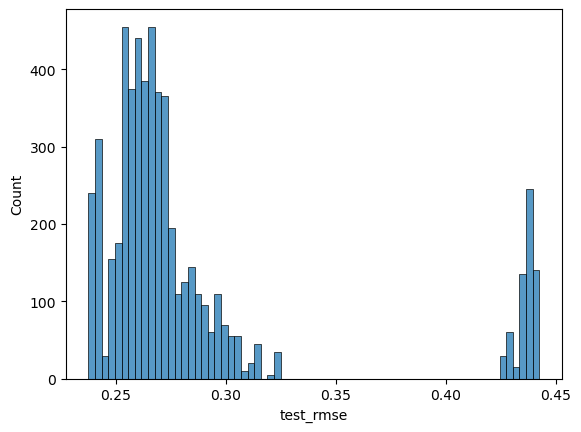

In [9]:
import seaborn as sns
sns.histplot(data=csv_file, x='test_rmse')

In [14]:
csv_file.sort_values(by='test_rmse').head(50)

,Unnamed: 0,gamma,max_depth,reg_lambda,min_child_weight,eta,num_boost,test_rmse
4703,4703,0.0500,3.0,5.0,0.0050,0.30,41.0,0.237467
4694,4694,0.0500,3.0,5.0,0.0010,0.30,41.0,0.237467
4721,4721,0.0500,3.0,5.0,0.0500,0.30,41.0,0.237467
4712,4712,0.0500,3.0,5.0,0.0100,0.30,41.0,0.237467
4685,4685,0.0500,3.0,5.0,0.0005,0.30,41.0,0.237467
212,212,0.0005,3.0,5.0,0.0100,0.30,50.0,0.237590
203,203,0.0005,3.0,5.0,0.0050,0.30,50.0,0.237590
221,221,0.0005,3.0,5.0,0.0500,0.30,50.0,0.237590
1337,1337,0.0010,3.0,5.0,0.0100,0.30,50.0,0.237590
1319,1319,0.0010,3.0,5.0,0.0010,0.30,50.0,0.237590


In [27]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from itertools import product
from pathlib import Path
import os

import multiprocessing

load_path = Path(os.getcwd()).parents[0]/Path('dataset/datasets/model_ready/train.csv')
train_data = pd.read_csv(load_path, index_col='Label')

X = train_data[['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_landfalling_omega500', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']]
snow_var = 'cumulative_snowfall_ais'
temp_var = 'max_2m_temp_ais'


# some basic cross validation
# for snowfall
etas = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.3])
# units of Y are in gigatons, a loss of 1 will be really
# high, so that seems like a reasonable upper bound
gammas = np.array([0.0005, 0.001, 0.005, 0.01, 0.05])
# intuition tells me we won't need to go THAT deep
max_depth = np.array([3, 7, 10, 15, 30])
# don't have a great intuition on this, mostly testing
lambdas = np.array([0, 0.3, 0.7, 1, 5])
# same
min_child_weights = np.array([0.0005, 0.001, 0.005, 0.01, 0.05])
# since we're doing early stopping, this should be good
nrounds = 500
early_stopping_rounds = 10
tree_method = 'exact'
booster = 'gbtree'

hyperparams_lst = list(product(gammas, max_depth, lambdas, min_child_weights))

# function that will be run in parallel on chunks on the hyperparameters
def process_hyperparam_chunk(lst):

    train_data = pd.read_csv(load_path, index_col='Label')
    X = train_data[['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_landfalling_omega500', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']]

    num_eta = len(etas)
    results_lst = np.zeros((len(etas)*len(lst), len(lst[0]) + 3))
    
    for i, param_set in enumerate(lst):
        for j, eta in enumerate(etas):
            params = dict(booster='gbtree',
                   eta=eta,
                   gamma=param_set[0],
                   max_depth=param_set[1],
                   reg_lambda=param_set[2],
                   min_child_weight=param_set[3],
                   tree_method=tree_method)
            dtrain = xgb.DMatrix(X, label=train_data[snow_var])
            res = xgb.cv(params,
                   dtrain,
                   nrounds,
                   nfold=5,
                   seed=12345,
                   early_stopping_rounds=early_stopping_rounds)
            results_lst[i*num_eta + j,:] = np.array(list(param_set) + [eta] + [res.shape[0]] + [float(res['test-rmse-mean'].iloc[-1])])

            results_df = pd.DataFrame(results_lst, columns=['gamma', 'max_depth', 'reg_lambda', 'min_child_weight', 'eta', 'num_boost', 'test_rmse'])

    return results_df

# creating the chunks of hyperparameters
chunk_lst = []
chunk_size = 10


for i in range(0, len(hyperparams_lst), chunk_size):
    chunk_lst.append(hyperparams_lst[i:i + chunk_size])

In [20]:
len(chunk_lst[0])

10

In [21]:
chunk_lst_lite = chunk_lst[0:10]

In [22]:
n_proc=1

In [23]:
if __name__ == '__main__':
    with multiprocessing.Pool(processes=n_proc) as pool:
        results = pool.map(process_hyperparam_chunk, chunk_lst_lite)
    full_df = pd.concat(results)
    full_df.to_csv('cv_res.csv')

KeyboardInterrupt: 

In [28]:
res = process_hyperparam_chunk(chunk_lst_lite[0])

In [35]:
pd.concat([res, res], ignore_index=True)

,gamma,max_depth,reg_lambda,min_child_weight,eta,num_boost,test_rmse
0,0.0005,3.0,0.0,0.0005,0.001,500.0,0.439850
1,0.0005,3.0,0.0,0.0005,0.010,500.0,0.241150
2,0.0005,3.0,0.0,0.0005,0.050,129.0,0.240416
3,0.0005,3.0,0.0,0.0005,0.100,52.0,0.239690
4,0.0005,3.0,0.0,0.0005,0.200,41.0,0.237277
...,...,...,...,...,...,...,...
115,0.0005,3.0,0.3,0.0500,0.010,500.0,0.241581
116,0.0005,3.0,0.3,0.0500,0.050,167.0,0.240622
117,0.0005,3.0,0.3,0.0500,0.100,61.0,0.239432
118,0.0005,3.0,0.3,0.0500,0.200,57.0,0.239628


In [36]:
train_data[snow_var]

Label
1980_1     0.047941
1980_2     0.621764
1980_5     1.410684
1980_6     0.006909
1980_7     0.237743
             ...   
2022_84    2.326996
2022_85    0.009465
2022_87    0.319278
2022_89    0.128313
2022_90    0.052592
Name: cumulative_snowfall_ais, Length: 2471, dtype: float64